<a href="https://colab.research.google.com/github/adarsh-crafts/BSDA5002-Mathematical-Foundations-of-Generative-AI/blob/main/02%20Convolutional%20GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Generative Adversarial Networks (GANs)

## Setup

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as transforms
import torchvision
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
# set devive
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else 'cpu'
print(device)

mps


## Hyperparams

In [ ]:
batch_size = 64
noise_dim = 100
img_dim = 3
learning_rate = 2e-4

## Create DataLoaders

In [ ]:
# download data & create dataloaders

transformation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.CIFAR10(
    root='data',
    train=True,
    download=False,
    transform=transformation
)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

## Define GAN - Generator & Discriminator

<u>**Batch Normalization**</u>

* Earlier layer weight updates → activation distribution shifts across training
* Example: Layer input changes from `~N(0,1) → ~N(5,10)`, now Downstream layers must continuously re-adapt → optimization becomes harder
* BatchNorm normalizes activations per mini-batch: `N(Mean ≈ 0, Variance ≈ 1)`
* Prevents unstable activation scales, Improves gradient flow, Allows larger learning rates, Faster, more stable convergence
   
* *Learnable parameters:*  

  [ `y = \gamma \hat{x} + \beta` ], where `(\gamma) = scale` and `(\beta) = shift`

  * If normalization is ideal: (\gamma \approx 1,\ \beta \approx 0)
  * Otherwise learns different (\gamma,\beta) values for whatever suitable distribution


<u>**Image Dimensions through the layers:**</u>  

img dim through the layer: `(Height - 1) × stride - 2×padding + kernel`

<u>**LeakyReLU:**</u>
```bash
f(x)={x, if x>0
     {αx​, if x≤0​
```
- LeakyReLU prevents the dying ReLU problem.
- In GANs, especially the Discriminator, neurons dying is a common problem.

In [ ]:
class Generator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.hidden = nn.Sequential(
            nn.ConvTranspose2d(in_channels=input_dim, out_channels=256, kernel_size=4, stride=1, padding=0),  # img: (batch, 256, 4, 4)
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # (batch, 128, 8, 8)
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # (batch, 64, 16, 16)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),     # batch(3, 32, 32)
            nn.Tanh()
        )

    def forward(self, x):
        return self.hidden(x)


class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.hidden = nn.Sequential(
            nn.Conv2d(input_dim, 64, 4, 2, 1),  # (batch, 64, 16, 16)
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),    # (batch, 128, 8, 8)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),   # (batch, 256, 4, 4)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 4, 1, 0),     # (batch, 1, 1, 1)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.hidden(x).view(-1, 1)

In [ ]:
# instantiate the models
generator = Generator(input_dim=noise_dim).to(device)
discriminator = Discriminator(input_dim=img_dim).to(device)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=learning_rate)

# loss fn
criterion = nn.BCELoss()

## Train Model

In [ ]:
'''
to understand the progression of improvement in each epoch
this function will be used to display the generated image at each epoch.
'''

def show_generated_images(epoch, generator, fixed_noise):
  generator.eval()
  with torch.no_grad():
    fake_imgs = generator(fixed_noise).cpu()
    fake_imgs = fake_imgs * 0.5 + 0.5   # De-normalize

  grid = torchvision.utils.make_grid(fake_imgs, nrow=8)
  plt.imshow(grid.permute(1, 2, 0))
  plt.title(f'Images Generated @ Epoch: {epoch}')
  plt.show()

In [ ]:
def train(train_dataloader, epochs):
    for epoch in range(epochs):
        for batch_idx, (X, _) in enumerate(train_dataloader):

            # train DISCRIMINATOR
            discriminator.train()

            batch_size = X.size(0)
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # objective fn term 1
            d_outputs_real = discriminator(X.to(device))
            d_loss_real = criterion(d_outputs_real, real_labels)

            # objective fn term 2
            z = torch.randn(batch_size, noise_dim, 1, 1).to(device)     # cos we are using 4D tensor for generator input
            g_outputs = generator(z)
            d_outputs_fake = discriminator(g_outputs)
            d_loss_fake = criterion(d_outputs_fake, fake_labels)

            # Total discriminator loss
            d_loss = d_loss_real + d_loss_fake

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            ## train GENERATOR
            generator.train()

            z = torch.randn(batch_size, noise_dim, 1, 1).to(device)     # cos we are using 4D tensor for generator input
            g_outputs = generator(z)
            d_outputs = discriminator(g_outputs)

            g_loss = criterion(d_outputs, real_labels)

            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

        print(f"Epoch [{epoch+1}/{epochs}], d_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}")
        if (epoch+1) % 10 == 0:
            fixed_noise = torch.randn(64, noise_dim, 1, 1).to(device)
            show_generated_images(epoch+1, generator, fixed_noise)

Epoch [1/50], d_loss: 0.0636, g_loss: 8.8525
Epoch [2/50], d_loss: 0.0870, g_loss: 15.1181
Epoch [3/50], d_loss: 0.0048, g_loss: 6.3785
Epoch [4/50], d_loss: 0.0976, g_loss: 4.5577
Epoch [5/50], d_loss: 0.0152, g_loss: 7.9192
Epoch [6/50], d_loss: 0.0005, g_loss: 7.0884
Epoch [7/50], d_loss: 0.7262, g_loss: 5.1086
Epoch [8/50], d_loss: 0.1814, g_loss: 7.5903
Epoch [9/50], d_loss: 0.3243, g_loss: 7.5442
Epoch [10/50], d_loss: 0.0131, g_loss: 8.5234


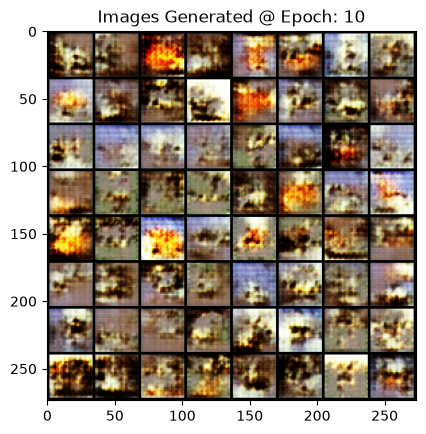

Epoch [11/50], d_loss: 0.1182, g_loss: 4.8032
Epoch [12/50], d_loss: 0.0313, g_loss: 7.7457
Epoch [13/50], d_loss: 0.1717, g_loss: 5.5265
Epoch [14/50], d_loss: 0.8115, g_loss: 6.0310
Epoch [15/50], d_loss: 0.0134, g_loss: 4.9518
Epoch [16/50], d_loss: 0.3635, g_loss: 5.0764
Epoch [17/50], d_loss: 0.0316, g_loss: 4.8920
Epoch [18/50], d_loss: 0.4347, g_loss: 7.2542
Epoch [19/50], d_loss: 0.2339, g_loss: 5.8231
Epoch [20/50], d_loss: 0.0149, g_loss: 5.4797


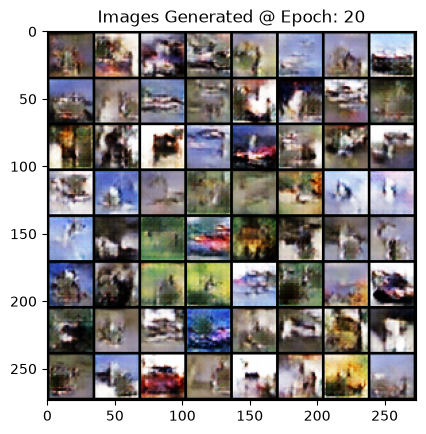

Epoch [21/50], d_loss: 0.0632, g_loss: 3.8200
Epoch [22/50], d_loss: 0.1241, g_loss: 5.6126
Epoch [23/50], d_loss: 0.3971, g_loss: 2.4701
Epoch [24/50], d_loss: 0.3755, g_loss: 4.0020
Epoch [25/50], d_loss: 0.0207, g_loss: 4.9692
Epoch [26/50], d_loss: 0.1213, g_loss: 4.4072
Epoch [27/50], d_loss: 0.1278, g_loss: 4.7429
Epoch [28/50], d_loss: 0.2899, g_loss: 4.3814
Epoch [29/50], d_loss: 0.3486, g_loss: 3.7770
Epoch [30/50], d_loss: 0.3426, g_loss: 3.0045


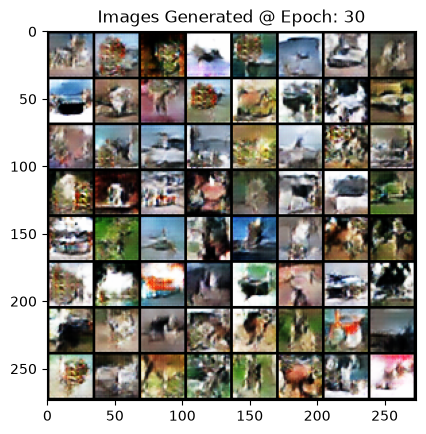

Epoch [31/50], d_loss: 0.5735, g_loss: 8.1631
Epoch [32/50], d_loss: 0.0584, g_loss: 4.5741
Epoch [33/50], d_loss: 0.2286, g_loss: 3.2511
Epoch [34/50], d_loss: 0.0895, g_loss: 5.3870
Epoch [35/50], d_loss: 0.0276, g_loss: 5.3465
Epoch [36/50], d_loss: 0.0985, g_loss: 7.3429
Epoch [37/50], d_loss: 0.1886, g_loss: 1.7824
Epoch [38/50], d_loss: 0.0488, g_loss: 3.1503
Epoch [39/50], d_loss: 0.5387, g_loss: 2.7171
Epoch [40/50], d_loss: 0.1166, g_loss: 6.9416


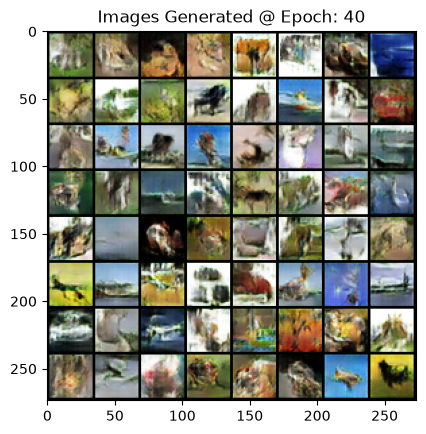

Epoch [41/50], d_loss: 0.1187, g_loss: 8.4409
Epoch [42/50], d_loss: 0.2392, g_loss: 1.9807
Epoch [43/50], d_loss: 0.0582, g_loss: 4.8489
Epoch [44/50], d_loss: 1.1843, g_loss: 3.9195
Epoch [45/50], d_loss: 0.4555, g_loss: 4.4494
Epoch [46/50], d_loss: 0.0761, g_loss: 5.9309
Epoch [47/50], d_loss: 0.5833, g_loss: 3.3208
Epoch [48/50], d_loss: 0.0850, g_loss: 3.2361
Epoch [49/50], d_loss: 0.0986, g_loss: 5.3190
Epoch [50/50], d_loss: 0.0879, g_loss: 4.7600


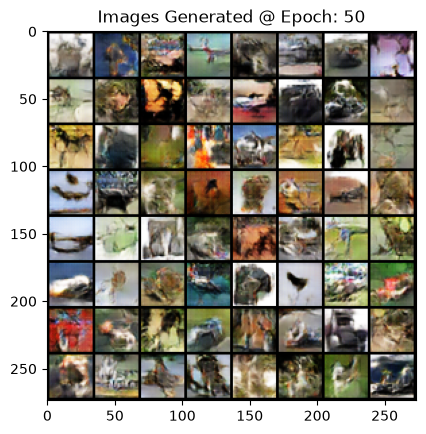

In [ ]:
train(train_dataloader, epochs=50)